# Actividad Evaluativa

### Ejercicio 1.

Recorta el punto de interés de la imagen1.jpg tal cual se muestra en la figura, guarda la
imagen recortada en tu disco local, y muestra la imagen original y la recortada con axis
(imagen a colores)

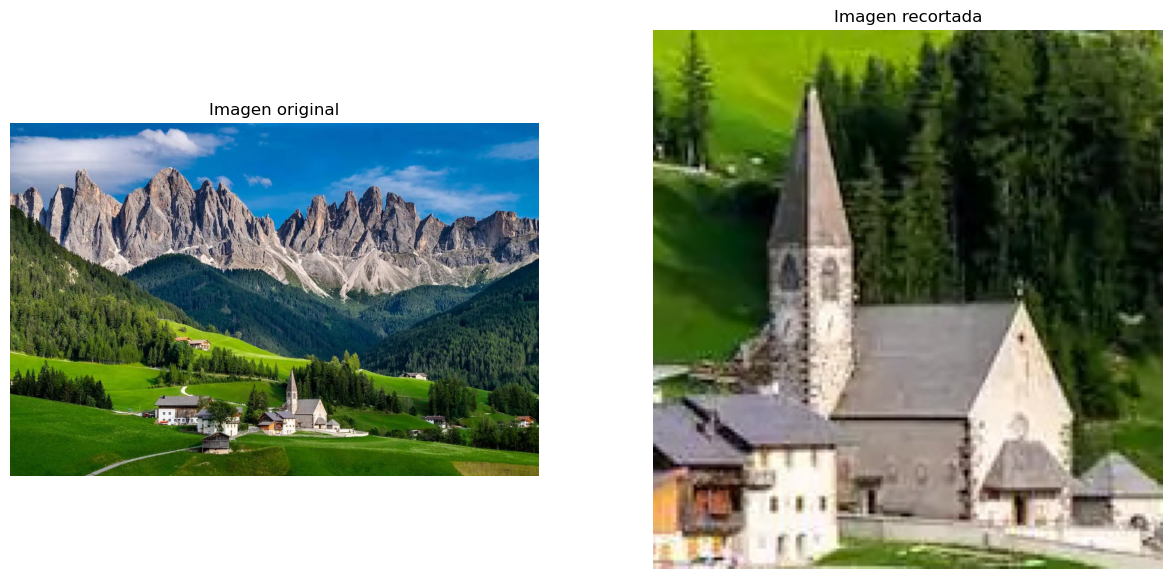

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('./images/imagen1.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img[610:795, 665:840])
plt.title('Imagen recortada')
plt.axis('off')

plt.show()

plt.imsave('./images/actividad-7/imagen_recortada.jpg', img[610:795, 665:840])

### Ejercicio 2.

Genera un degradado lineal a colores.

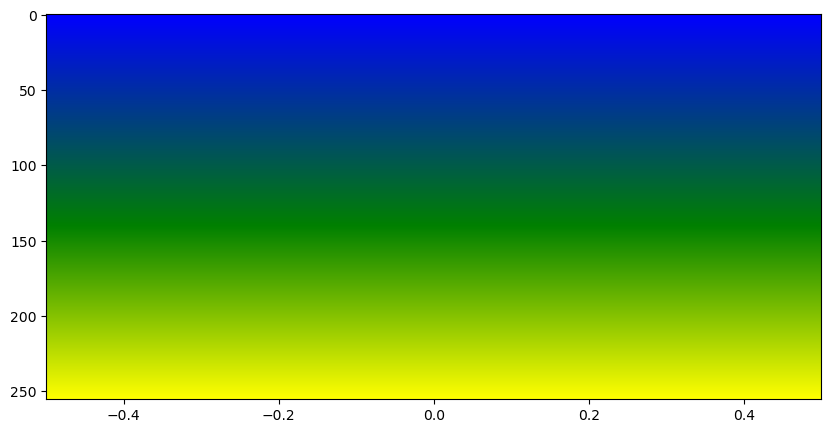

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Definicion de colores
colores = [(0, 'blue'), (0.55, 'green'), (1, 'yellow')] # Para generar escala de colores
cmap = LinearSegmentedColormap.from_list('degradado', colores) # Generamos el colormap a traves de nuestro array de colores
imagen_degradado = cmap(np.linspace(0, 1, 256).reshape(-1, 1)) # Generamos la imagen de degradado

plt.imshow(imagen_degradado, aspect='auto')
plt.show()

### Ejercicio 3.

Genera una imagen semejante a un tablero de ajedrez tomando en cuenta que cada
casilla debe medir 100x100 px.

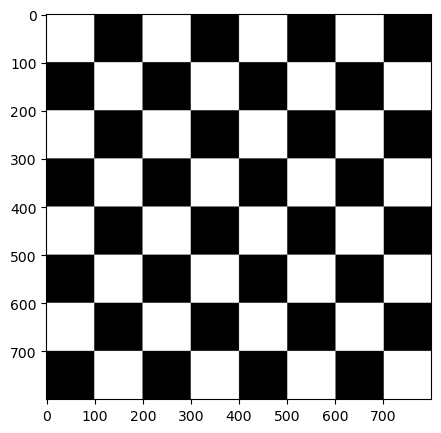

In [11]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

plt.rcParams['figure.figsize'] = [10, 5]
imgSize = 800

R = np.ones((imgSize, imgSize)) * 255
G = np.ones((imgSize, imgSize)) * 255
B = np.ones((imgSize, imgSize)) * 255

for i in range(imgSize):
  for j in range(imgSize):
    if i // 100 % 2 == 0 and j // 100 % 2 == 1:
      R[i][j] = 0
      G[i][j] = 0
      B[i][j] = 0
    if i // 100 % 2 == 1 and j // 100 % 2 == 0:
      R[i][j] = 0
      G[i][j] = 0
      B[i][j] = 0

img = np.dstack((R, G, B))
img = np.array(img, dtype=int)

plt.figure()
plt.imshow(img)

cv2.imwrite('images/activdad-aula-generado.png', img)
plt.show()

plt.imsave('./images/actividad-7/imagen-tablero.png', img.astype(np.uint8))

### Ejercicio 5.

Tomando en cuenta la imagen1.jpg aplica un degradado lineal en ella.

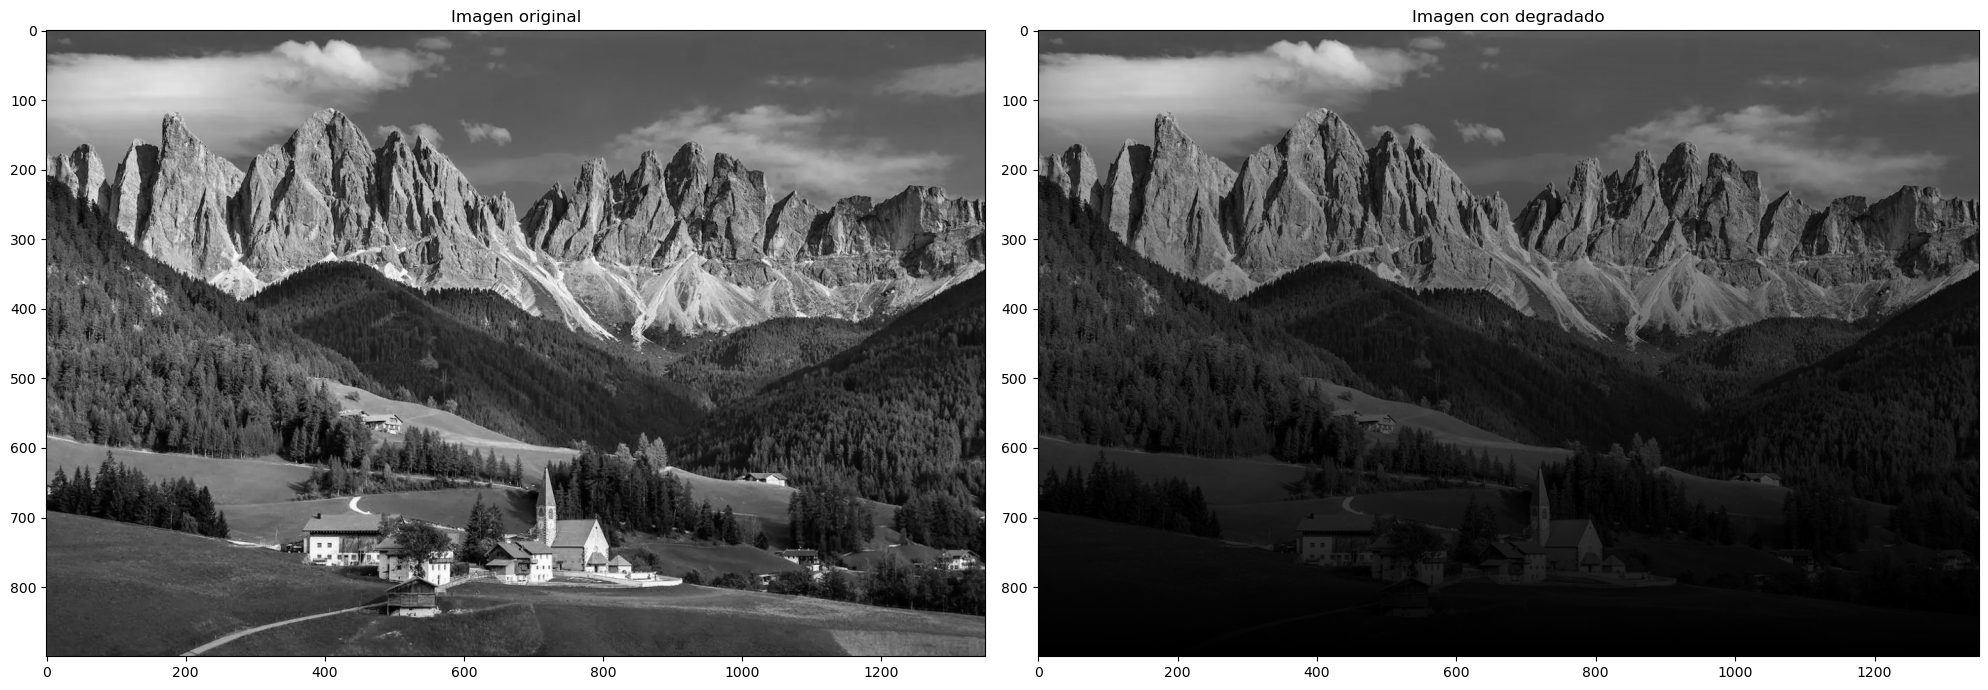

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

img = cv2.imread('./images/imagen1.jpg', 0)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Cargar la imagen correctamente (sin mezclar modos)
# img = cv2.imread('./images/imagen1.jpg')
# img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Crear un degradado del mismo tamaño que la imagen
height, width = img.shape[:2]
gradient = np.zeros((height, width), dtype=np.float32)

# Degradado vertical (de arriba hacia abajo)
for y in range(height):
  gradient[y, :] = 1 - y / height

# Crear máscara con el degradado
mask = gradient[:, :, np.newaxis]  # Añadir dimensión para multiplicar con la imagen

# Aplicar el degradado (transparencia gradual)
result = img * mask

plt.figure(figsize=(20, 7))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Imagen original')

plt.subplot(1, 2, 2)
plt.imshow(result.astype(np.uint8), aspect='auto')
plt.title('Imagen con degradado')

plt.tight_layout()
plt.show()

plt.imsave('./images/actividad-7/imagen-degradado.jpg', result.astype(np.uint8))